In [2]:
!pip install seaborn

In [3]:
# Import necessary libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from pathlib import Path
from collections import Counter
import warnings
from tqdm.auto import tqdm
import re

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Set random seed for reproducibility
np.random.seed(42)

/opt/conda/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Data Loading

Load data from both datasets:
- **IM2LATEX**: Printed LaTeX formulas from papers
- **CROHME**: Handwritten mathematical expressions

In [4]:
# Define paths
IM2LATEX_IMG_PATH = Path("/app/data/IM2LATEX/image")
IM2LATEX_LABEL_PATH = Path("/app/data/IM2LATEX/label")
CROHME_IMG_PATH = Path("/app/data/CHROME/ground_truth/images")
CROHME_CSV_PATH = Path("/app/data/CHROME/ground_truth/dataset.csv")

# Load IM2LATEX datasets
im2latex_train = pd.read_csv(IM2LATEX_LABEL_PATH / "im2latex_train.csv")
im2latex_val = pd.read_csv(IM2LATEX_LABEL_PATH / "im2latex_validate.csv")
im2latex_test = pd.read_csv(IM2LATEX_LABEL_PATH / "im2latex_test.csv")

# Combine all IM2LATEX data
im2latex_df = pd.concat([im2latex_train, im2latex_val, im2latex_test], ignore_index=True)
im2latex_df['dataset'] = 'IM2LATEX'
im2latex_df['image_path'] = im2latex_df['image'].apply(lambda x: IM2LATEX_IMG_PATH / x)

# Load CROHME dataset
crohme_df = pd.read_csv(CROHME_CSV_PATH)
crohme_df['dataset'] = 'CROHME'
crohme_df['image_path'] = crohme_df['image'].apply(lambda x: CROHME_IMG_PATH / x)

print(f"IM2LATEX samples: {len(im2latex_df):,}")
print(f"CROHME samples: {len(crohme_df):,}")
print(f"Total samples: {len(im2latex_df) + len(crohme_df):,}")

IM2LATEX samples: 94,000
CROHME samples: 18,855
Total samples: 112,855


---

# PART 1: IMAGE ANALYSIS

Analyze image characteristics to determine optimal input dimensions.

## 1.1 Resolution Distribution Analysis

Mathematical formulas tend to be **wide and short**.

In [5]:
def extract_image_dimensions(df, sample_size=None):
    """
    Extract width and height from images.
    
    Args:
        df: DataFrame with 'image_path' column
        sample_size: If specified, randomly sample images (for faster processing)
    
    Returns:
        DataFrame with width, height, and aspect_ratio columns
    """
    if sample_size and sample_size < len(df):
        df_sample = df.sample(n=sample_size, random_state=42)
    else:
        df_sample = df.copy()
    
    dimensions = []
    
    for img_path in tqdm(df_sample['image_path'], desc="Loading images"):
        try:
            if os.path.exists(img_path):
                with Image.open(img_path) as img:
                    width, height = img.size
                    dimensions.append({
                        'width': width,
                        'height': height,
                        'aspect_ratio': width / height if height > 0 else 0
                    })
            else:
                dimensions.append({'width': None, 'height': None, 'aspect_ratio': None})
        except Exception as e:
            dimensions.append({'width': None, 'height': None, 'aspect_ratio': None})
    
    dim_df = pd.DataFrame(dimensions)
    return pd.concat([df_sample.reset_index(drop=True), dim_df], axis=1)

# Extract dimensions (sample for faster processing)
print("Processing IM2LATEX images...")
im2latex_with_dims = extract_image_dimensions(im2latex_df, sample_size=5000)

print("Processing CROHME images...")
crohme_with_dims = extract_image_dimensions(crohme_df)  # CROHME is smaller, process all

Processing IM2LATEX images...


Loading images:   0%|          | 0/5000 [00:00<?, ?it/s]

Loading images: 100%|██████████| 5000/5000 [01:59<00:00, 41.73it/s]


Processing CROHME images...


Loading images: 100%|██████████| 18855/18855 [05:44<00:00, 54.66it/s] 


In [6]:
# Remove rows with missing dimensions
im2latex_clean = im2latex_with_dims.dropna(subset=['width', 'height'])
crohme_clean = crohme_with_dims.dropna(subset=['width', 'height'])

# Statistics
print("\n=== IM2LATEX Image Dimensions ===")
print(f"Width  - Mean: {im2latex_clean['width'].mean():.1f}, Median: {im2latex_clean['width'].median():.1f}, Std: {im2latex_clean['width'].std():.1f}")
print(f"Height - Mean: {im2latex_clean['height'].mean():.1f}, Median: {im2latex_clean['height'].median():.1f}, Std: {im2latex_clean['height'].std():.1f}")
print(f"Aspect Ratio - Mean: {im2latex_clean['aspect_ratio'].mean():.2f}, Median: {im2latex_clean['aspect_ratio'].median():.2f}")

print("\n=== CROHME Image Dimensions ===")
print(f"Width  - Mean: {crohme_clean['width'].mean():.1f}, Median: {crohme_clean['width'].median():.1f}, Std: {crohme_clean['width'].std():.1f}")
print(f"Height - Mean: {crohme_clean['height'].mean():.1f}, Median: {crohme_clean['height'].median():.1f}, Std: {crohme_clean['height'].std():.1f}")
print(f"Aspect Ratio - Mean: {crohme_clean['aspect_ratio'].mean():.2f}, Median: {crohme_clean['aspect_ratio'].median():.2f}")


=== IM2LATEX Image Dimensions ===
Width  - Mean: 283.9, Median: 256.0, Std: 113.6
Height - Mean: 53.3, Median: 64.0, Std: 18.1
Aspect Ratio - Mean: 5.85, Median: 5.00

=== CROHME Image Dimensions ===
Width  - Mean: 400.0, Median: 400.0, Std: 0.0
Height - Mean: 400.0, Median: 400.0, Std: 0.0
Aspect Ratio - Mean: 1.00, Median: 1.00


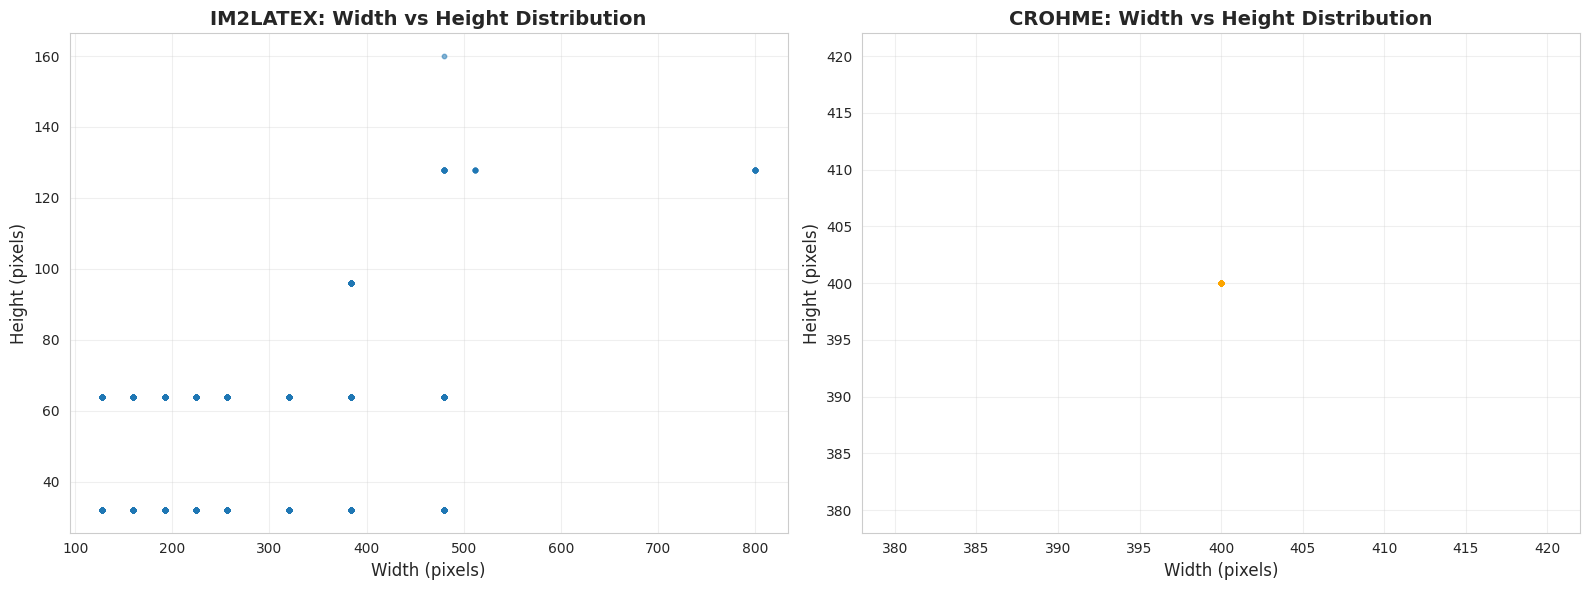

In [7]:
# Scatter plot: Width vs Height
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# IM2LATEX
axes[0].scatter(im2latex_clean['width'], im2latex_clean['height'], alpha=0.3, s=10)
axes[0].set_xlabel('Width (pixels)', fontsize=12)
axes[0].set_ylabel('Height (pixels)', fontsize=12)
axes[0].set_title('IM2LATEX: Width vs Height Distribution', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# CROHME
axes[1].scatter(crohme_clean['width'], crohme_clean['height'], alpha=0.3, s=10, color='orange')
axes[1].set_xlabel('Width (pixels)', fontsize=12)
axes[1].set_ylabel('Height (pixels)', fontsize=12)
axes[1].set_title('CROHME: Width vs Height Distribution', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

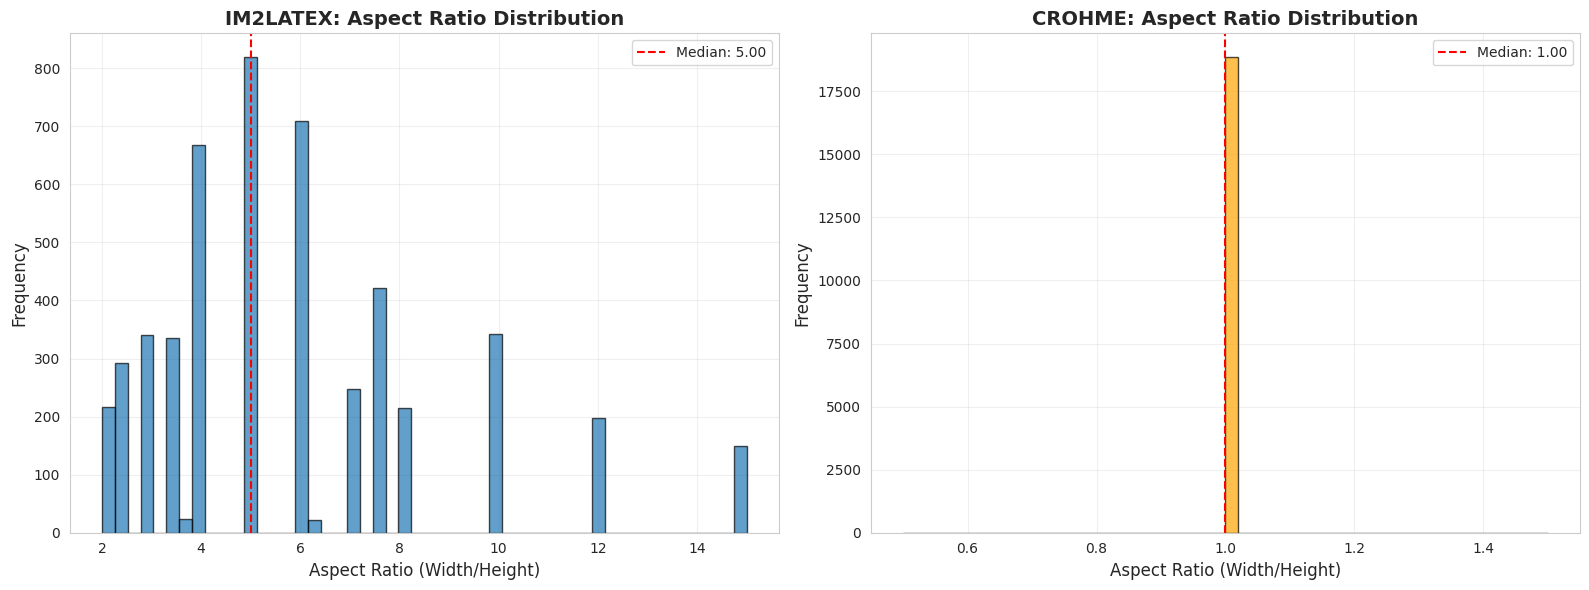

In [8]:
# Aspect Ratio Distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# IM2LATEX
axes[0].hist(im2latex_clean['aspect_ratio'], bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(im2latex_clean['aspect_ratio'].median(), color='red', linestyle='--', 
                label=f'Median: {im2latex_clean["aspect_ratio"].median():.2f}')
axes[0].set_xlabel('Aspect Ratio (Width/Height)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('IM2LATEX: Aspect Ratio Distribution', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# CROHME
axes[1].hist(crohme_clean['aspect_ratio'], bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[1].axvline(crohme_clean['aspect_ratio'].median(), color='red', linestyle='--',
                label=f'Median: {crohme_clean["aspect_ratio"].median():.2f}')
axes[1].set_xlabel('Aspect Ratio (Width/Height)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('CROHME: Aspect Ratio Distribution', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [9]:
# Percentile analysis for determining input size
percentiles = [50, 75, 90, 95, 99]

print("\n=== IM2LATEX Percentiles ===")
for p in percentiles:
    w = np.percentile(im2latex_clean['width'], p)
    h = np.percentile(im2latex_clean['height'], p)
    print(f"{p}th percentile - Width: {w:.0f}, Height: {h:.0f}")

print("\n=== CROHME Percentiles ===")
for p in percentiles:
    w = np.percentile(crohme_clean['width'], p)
    h = np.percentile(crohme_clean['height'], p)
    print(f"{p}th percentile - Width: {w:.0f}, Height: {h:.0f}")


=== IM2LATEX Percentiles ===
50th percentile - Width: 256, Height: 64
75th percentile - Width: 384, Height: 64
90th percentile - Width: 480, Height: 64
95th percentile - Width: 480, Height: 64
99th percentile - Width: 480, Height: 128

=== CROHME Percentiles ===
50th percentile - Width: 400, Height: 400
75th percentile - Width: 400, Height: 400
90th percentile - Width: 400, Height: 400
95th percentile - Width: 400, Height: 400
99th percentile - Width: 400, Height: 400


### 📊 Recommendation for Input Size

Based on the analysis above:
- Formulas are predominantly **wide and short** (high aspect ratio)
- Suggested input sizes:
  - **Option 1**: Fixed size `128×512` or `96×384` (good for most formulas)
  - **Option 2**: Fixed height (e.g., 96 or 128), variable width with padding
  - Avoid square inputs (224×224) as they cause excessive distortion

## 1.2 Pixel Intensity Analysis

Analyze brightness and contrast to determine normalization parameters and preprocessing needs.

In [10]:
def analyze_pixel_intensity(df, sample_size=500, dataset_name=""):
    """
    Analyze pixel intensity statistics.
    
    Args:
        df: DataFrame with 'image_path' column
        sample_size: Number of images to sample
        dataset_name: Name for display
    
    Returns:
        Dictionary with mean, std, and pixel values
    """
    df_sample = df.sample(n=min(sample_size, len(df)), random_state=42)
    
    all_pixels = []
    image_means = []
    image_stds = []
    
    for img_path in tqdm(df_sample['image_path'], desc=f"Analyzing {dataset_name} pixels"):
        try:
            if os.path.exists(img_path):
                with Image.open(img_path) as img:
                    # Convert to grayscale if needed
                    if img.mode != 'L':
                        img = img.convert('L')
                    
                    img_array = np.array(img).astype(np.float32) / 255.0
                    image_means.append(img_array.mean())
                    image_stds.append(img_array.std())
                    
                    # Sample pixels for histogram
                    sampled_pixels = np.random.choice(img_array.flatten(), 
                                                      size=min(1000, img_array.size), 
                                                      replace=False)
                    all_pixels.extend(sampled_pixels)
        except Exception as e:
            continue
    
    return {
        'mean': np.mean(image_means),
        'std': np.mean(image_stds),
        'pixels': np.array(all_pixels),
        'image_means': image_means,
        'image_stds': image_stds
    }

# Analyze both datasets
im2latex_intensity = analyze_pixel_intensity(im2latex_clean, sample_size=500, dataset_name="IM2LATEX")
crohme_intensity = analyze_pixel_intensity(crohme_clean, sample_size=500, dataset_name="CROHME")

print(f"\nIM2LATEX - Mean: {im2latex_intensity['mean']:.4f}, Std: {im2latex_intensity['std']:.4f}")
print(f"CROHME   - Mean: {crohme_intensity['mean']:.4f}, Std: {crohme_intensity['std']:.4f}")

Analyzing CROHME pixels: 100%|██████████| 500/500 [00:11<00:00, 44.84it/s]


IM2LATEX - Mean: 0.9449, Std: 0.1888
CROHME   - Mean: 0.9889, Std: 0.1032


** Nhận xét:
- IM2LATEX có độ tương phản cao hơn, ảnh sắc nét hơn (std cao)
- CHROME có độ tương phản thấp hơn, chữ mờ hơn (std thấp)

---

# PART 2: LABEL ANALYSIS (LaTeX Formulas)

Critical for building tokenizer and determining sequence length.

## 2.1 Sequence Length Analysis

Determine optimal `MAX_SEQ_LEN` to avoid OOM errors.

In [12]:
def tokenize_formula(formula):
    """
    Simple tokenization by splitting on whitespace.
    This is a rough estimate - actual tokenization may differ.
    """
    if pd.isna(formula):
        return []
    return str(formula).split()

# Tokenize formulas
print("Tokenizing IM2LATEX formulas...")
im2latex_df['tokens'] = im2latex_df['formula'].apply(tokenize_formula)
im2latex_df['seq_len'] = im2latex_df['tokens'].apply(len)

print("Tokenizing CROHME formulas...")
crohme_df['tokens'] = crohme_df['formula'].apply(tokenize_formula)
crohme_df['seq_len'] = crohme_df['tokens'].apply(len)

# Statistics
print("\n=== IM2LATEX Sequence Length ===")
print(f"Mean: {im2latex_df['seq_len'].mean():.1f}")
print(f"Median: {im2latex_df['seq_len'].median():.1f}")
print(f"Std: {im2latex_df['seq_len'].std():.1f}")
print(f"Max: {im2latex_df['seq_len'].max()}")

print("\n=== CROHME Sequence Length ===")
print(f"Mean: {crohme_df['seq_len'].mean():.1f}")
print(f"Median: {crohme_df['seq_len'].median():.1f}")
print(f"Std: {crohme_df['seq_len'].std():.1f}")
print(f"Max: {crohme_df['seq_len'].max()}")

Tokenizing IM2LATEX formulas...
Tokenizing CROHME formulas...

=== IM2LATEX Sequence Length ===
Mean: 57.7
Median: 52.0
Std: 29.3
Max: 625

=== CROHME Sequence Length ===
Mean: 8.4
Median: 8.0
Std: 6.7
Max: 98


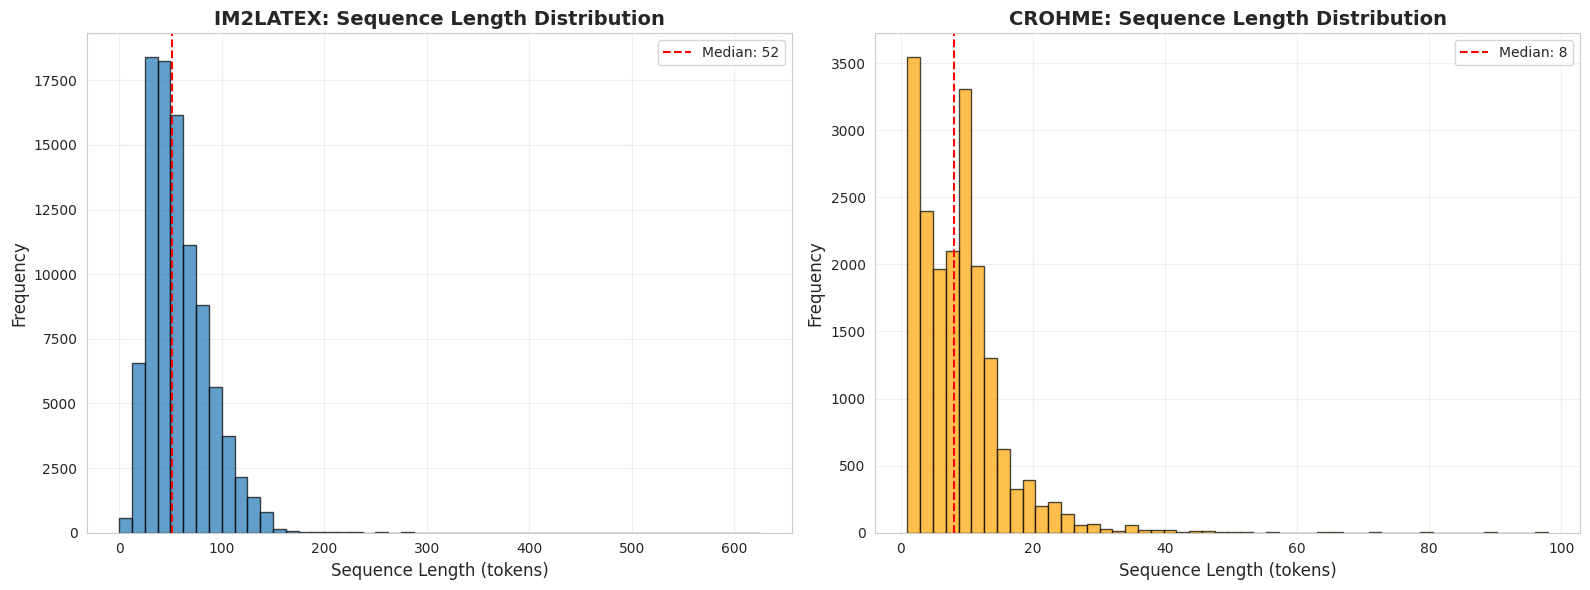

In [13]:
# Sequence length distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# IM2LATEX
axes[0].hist(im2latex_df['seq_len'], bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(im2latex_df['seq_len'].median(), color='red', linestyle='--',
                label=f"Median: {im2latex_df['seq_len'].median():.0f}")
axes[0].set_xlabel('Sequence Length (tokens)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('IM2LATEX: Sequence Length Distribution', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# CROHME
axes[1].hist(crohme_df['seq_len'], bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[1].axvline(crohme_df['seq_len'].median(), color='red', linestyle='--',
                label=f"Median: {crohme_df['seq_len'].median():.0f}")
axes[1].set_xlabel('Sequence Length (tokens)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('CROHME: Sequence Length Distribution', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
# Percentile analysis
percentiles = [90, 95, 99, 99.5]

print("\n=== IM2LATEX Sequence Length Percentiles ===")
for p in percentiles:
    val = np.percentile(im2latex_df['seq_len'], p)
    coverage = (im2latex_df['seq_len'] <= val).mean() * 100
    print(f"{p}th percentile: {val:.0f} tokens (covers {coverage:.1f}% of data)")

print("\n=== CROHME Sequence Length Percentiles ===")
for p in percentiles:
    val = np.percentile(crohme_df['seq_len'], p)
    coverage = (crohme_df['seq_len'] <= val).mean() * 100
    print(f"{p}th percentile: {val:.0f} tokens (covers {coverage:.1f}% of data)")


=== IM2LATEX Sequence Length Percentiles ===
90th percentile: 97 tokens (covers 90.2% of data)
95th percentile: 113 tokens (covers 95.2% of data)
99th percentile: 141 tokens (covers 99.1% of data)
99.5th percentile: 148 tokens (covers 99.5% of data)

=== CROHME Sequence Length Percentiles ===
90th percentile: 16 tokens (covers 91.4% of data)
95th percentile: 20 tokens (covers 95.2% of data)
99th percentile: 33 tokens (covers 99.1% of data)
99.5th percentile: 38 tokens (covers 99.5% of data)


### 📊 Recommendation for MAX_SEQ_LEN

- Choose `MAX_SEQ_LEN` based on percentiles (e.g., 95th or 99th)
- **Example**: If 95% of data has length < 150 tokens → set `MAX_SEQ_LEN = 150`
- Very long sequences should be removed or truncated during initial training for faster convergence

## 2.2 Token Frequency Analysis

Identify common and rare tokens for vocabulary construction.

In [15]:
# Collect all tokens
all_im2latex_tokens = []
for tokens in im2latex_df['tokens']:
    all_im2latex_tokens.extend(tokens)

all_crohme_tokens = []
for tokens in crohme_df['tokens']:
    all_crohme_tokens.extend(tokens)

# Count frequencies
im2latex_token_counter = Counter(all_im2latex_tokens)
crohme_token_counter = Counter(all_crohme_tokens)

print(f"\nIM2LATEX - Unique tokens: {len(im2latex_token_counter):,}")
print(f"CROHME   - Unique tokens: {len(crohme_token_counter):,}")
print(f"Total IM2LATEX tokens: {len(all_im2latex_tokens):,}")
print(f"Total CROHME tokens: {len(all_crohme_tokens):,}")


IM2LATEX - Unique tokens: 562
CROHME   - Unique tokens: 4,853
Total IM2LATEX tokens: 5,424,285
Total CROHME tokens: 157,674


In [16]:
# Top 50 most common tokens
print("\n=== IM2LATEX: Top 50 Most Common Tokens ===")
for token, count in im2latex_token_counter.most_common(50):
    print(f"{token:20s} : {count:6,}")


=== IM2LATEX: Top 50 Most Common Tokens ===
}                    : 904,750
{                    : 904,746
_                    : 292,622
^                    : 250,318
2                    : 153,649
(                    : 144,849
)                    : 144,656
1                    : 114,932
=                    : 114,787
-                    : 106,515
,                    : 96,937
\frac                : 78,832
+                    : 78,379
i                    : 64,290
0                    : 55,697
x                    : 48,870
n                    : 44,801
.                    : 43,375
\,                   : 42,833
d                    : 42,327
a                    : 42,048
\mu                  : 38,916
e                    : 31,260
k                    : 30,757
m                    : 29,537
r                    : 28,214
c                    : 28,014
p                    : 27,277
\partial             : 26,431
t                    : 26,102
\alpha               : 25,782
A              

In [17]:
print("\n=== CROHME: Top 50 Most Common Tokens ===")
for token, count in crohme_token_counter.most_common(50):
    print(f"{token:20s} : {count:6,}")


=== CROHME: Top 50 Most Common Tokens ===
{                    : 13,598
}                    : 13,567
+                    : 11,424
-                    :  7,822
=                    :  4,837
\mbox                :  3,648
2                    :  2,987
1                    :  2,823
x                    :  2,670
\frac                :  2,573
^                    :  2,056
&                    :  2,036
3                    :  1,833
\sqrt                :  1,810
0                    :  1,655
\times               :  1,615
y                    :  1,508
(                    :  1,400
a                    :  1,348
)                    :  1,321
\left                :  1,312
\right               :  1,312
b                    :  1,161
\sin                 :  1,127
d                    :  1,086
\tan                 :    967
z                    :    939
4                    :    930
\cos                 :    886
_                    :    880
{pmatrix}            :    824
1}                   :    8

In [18]:
# Rare tokens (appearing < 5 times)
im2latex_rare = {token: count for token, count in im2latex_token_counter.items() if count < 5}
crohme_rare = {token: count for token, count in crohme_token_counter.items() if count < 5}

print(f"\nIM2LATEX - Rare tokens (count < 5): {len(im2latex_rare):,}")
print(f"CROHME   - Rare tokens (count < 5): {len(crohme_rare):,}")

print("\n=== Sample of Rare Tokens (IM2LATEX) ===")
for token, count in list(im2latex_rare.items())[:30]:
    print(f"{token:30s} : {count}")


IM2LATEX - Rare tokens (count < 5): 115
CROHME   - Rare tokens (count < 5): 3,688

=== Sample of Rare Tokens (IM2LATEX) ===
\rightleftharpoons             : 3
\mathbin                       : 3
20                             : 1
\lceil                         : 4
\left\lfloor                   : 2
\do                            : 4
\em                            : 2
\mathaccent                    : 1
\grave                         : 3
\'                             : 4
\Huge                          : 4
0.9                            : 1
\succeq                        : 2
\left/                         : 1
\^                             : 1
\bigsqcup                      : 3
\brack                         : 1
\protecte                      : 1
1.7                            : 1
\protectu                      : 3
\asymp                         : 4
\bigvee                        : 1
\biggm                         : 1
\oslash                        : 3
\fill                          : 1


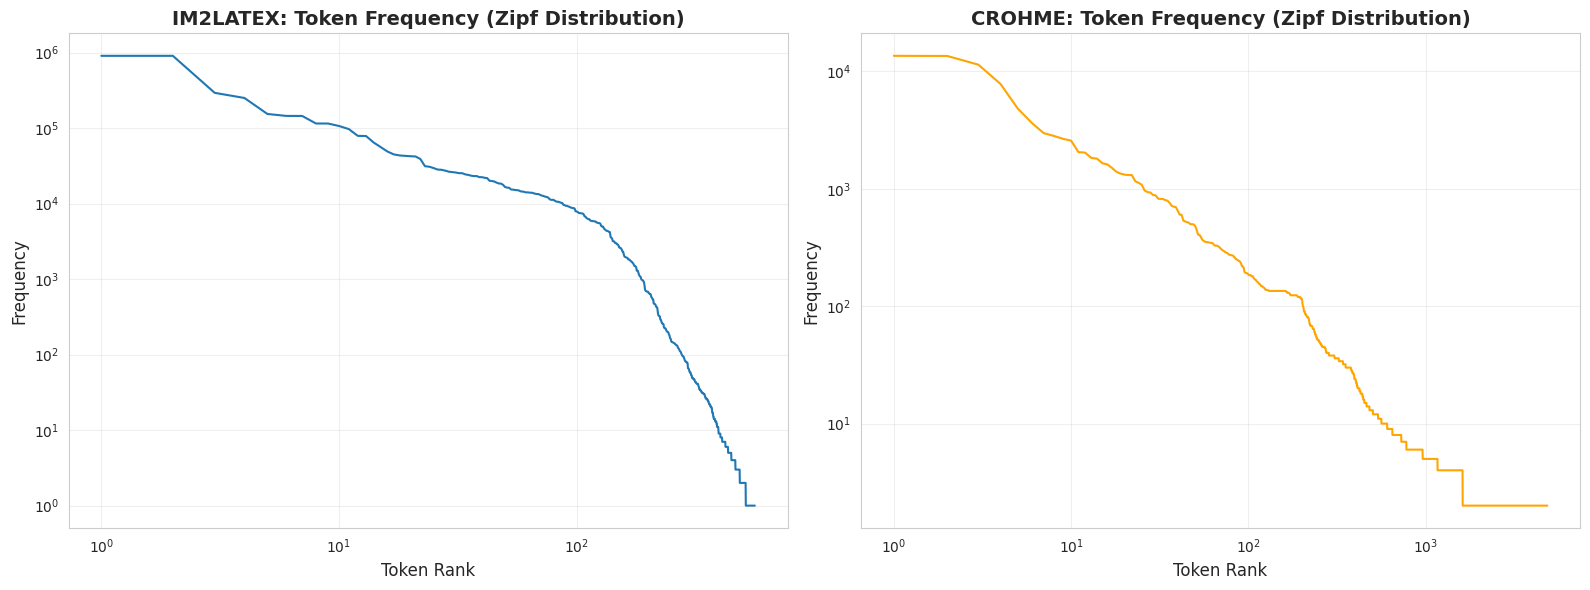

In [19]:
# Visualize token frequency distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# IM2LATEX
im2latex_counts = sorted(im2latex_token_counter.values(), reverse=True)
axes[0].plot(range(1, len(im2latex_counts) + 1), im2latex_counts)
axes[0].set_xlabel('Token Rank', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('IM2LATEX: Token Frequency (Zipf Distribution)', fontsize=14, fontweight='bold')
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].grid(True, alpha=0.3)

# CROHME
crohme_counts = sorted(crohme_token_counter.values(), reverse=True)
axes[1].plot(range(1, len(crohme_counts) + 1), crohme_counts, color='orange')
axes[1].set_xlabel('Token Rank', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('CROHME: Token Frequency (Zipf Distribution)', fontsize=14, fontweight='bold')
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 📊 Vocabulary Construction Recommendations

1. **Remove rare tokens** (e.g., appearing < 5 times) → replace with `<UNK>`
2. **Check for noise**: Custom LaTeX commands, typos, unusual symbols
3. **Balance check**: If certain symbols (e.g., `\frac`) vastly outnumber others (e.g., `\int`), consider weighted sampling or data augmentation
4. **Special tokens**: Add `<PAD>`, `<BOS>`, `<EOS>`, `<UNK>`

---

# PART 3: STRUCTURAL ANALYSIS

Analyze formula complexity for difficulty assessment.

## 3.1 Nesting Depth Analysis

Count depth of nested braces `{}` - indicates formula complexity.

In [20]:
def calculate_nesting_depth(formula):
    """
    Calculate maximum nesting depth of braces in a formula.
    """
    if pd.isna(formula):
        return 0
    
    max_depth = 0
    current_depth = 0
    
    for char in str(formula):
        if char == '{':
            current_depth += 1
            max_depth = max(max_depth, current_depth)
        elif char == '}':
            current_depth = max(0, current_depth - 1)
    
    return max_depth

# Calculate nesting depth
im2latex_df['nesting_depth'] = im2latex_df['formula'].apply(calculate_nesting_depth)
crohme_df['nesting_depth'] = crohme_df['formula'].apply(calculate_nesting_depth)

print("=== IM2LATEX Nesting Depth ===")
print(f"Mean: {im2latex_df['nesting_depth'].mean():.2f}")
print(f"Median: {im2latex_df['nesting_depth'].median():.0f}")
print(f"Max: {im2latex_df['nesting_depth'].max()}")

print("\n=== CROHME Nesting Depth ===")
print(f"Mean: {crohme_df['nesting_depth'].mean():.2f}")
print(f"Median: {crohme_df['nesting_depth'].median():.0f}")
print(f"Max: {crohme_df['nesting_depth'].max()}")

=== IM2LATEX Nesting Depth ===
Mean: 1.79
Median: 2
Max: 9

=== CROHME Nesting Depth ===
Mean: 1.09
Median: 1
Max: 9


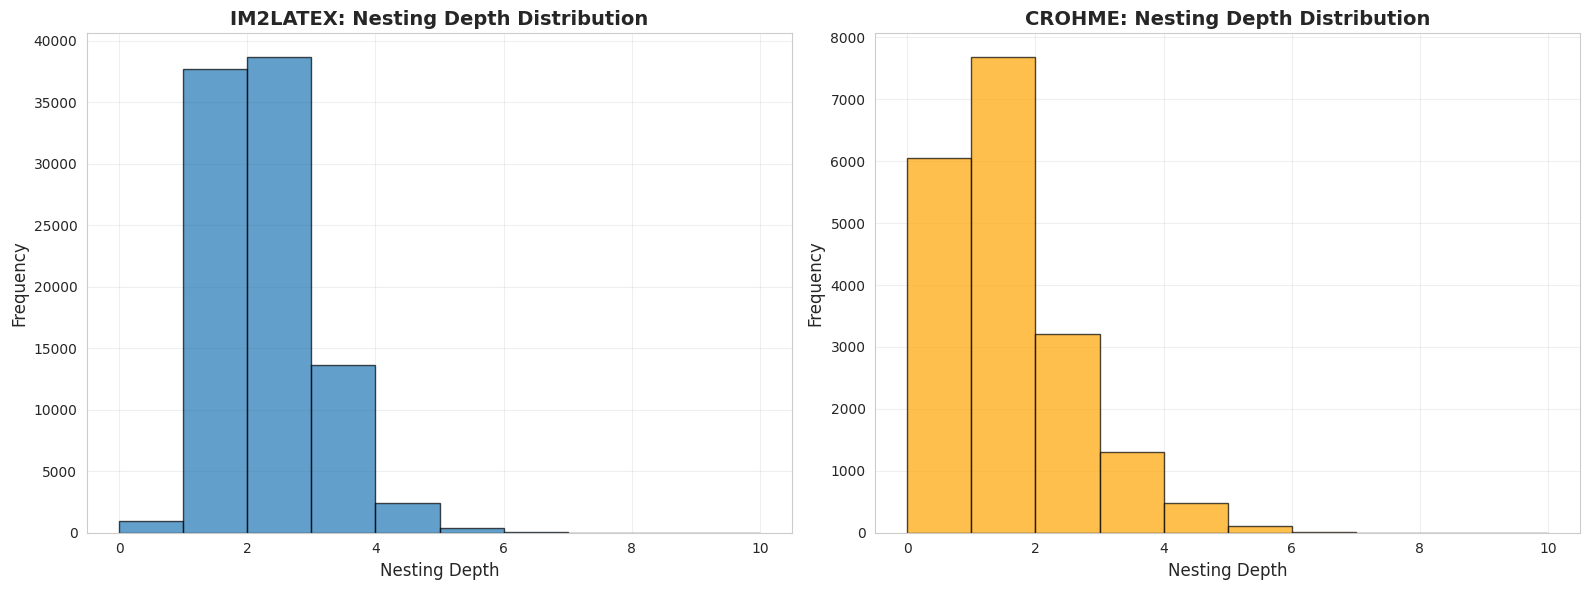

In [21]:
# Nesting depth distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# IM2LATEX
axes[0].hist(im2latex_df['nesting_depth'], bins=range(0, im2latex_df['nesting_depth'].max() + 2), 
             edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Nesting Depth', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('IM2LATEX: Nesting Depth Distribution', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# CROHME
axes[1].hist(crohme_df['nesting_depth'], bins=range(0, crohme_df['nesting_depth'].max() + 2),
             edgecolor='black', alpha=0.7, color='orange')
axes[1].set_xlabel('Nesting Depth', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('CROHME: Nesting Depth Distribution', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3.2 Formula Type Classification

Classify formulas by mathematical domain.

In [22]:
def classify_formula(formula):
    """
    Classify formula type based on special tokens.
    """
    if pd.isna(formula):
        return 'other'
    
    formula_str = str(formula).lower()
    types = []
    
    # Calculus
    if any(token in formula_str for token in ['\\int', '\\sum', '\\lim', '\\partial']):
        types.append('calculus')
    
    # Linear Algebra (matrices)
    if any(token in formula_str for token in ['\\begin{matrix', '\\begin{bmatrix', '\\begin{pmatrix']):
        types.append('matrix')
    
    # Fractions
    if '\\frac' in formula_str:
        types.append('fraction')
    
    # Subscript/Superscript heavy
    if formula_str.count('_') + formula_str.count('^') > 3:
        types.append('subscript_heavy')
    
    return ','.join(types) if types else 'simple'

# Classify formulas
im2latex_df['formula_type'] = im2latex_df['formula'].apply(classify_formula)
crohme_df['formula_type'] = crohme_df['formula'].apply(classify_formula)

print("=== IM2LATEX Formula Types ===")
print(im2latex_df['formula_type'].value_counts().head(20))

print("\n=== CROHME Formula Types ===")
print(crohme_df['formula_type'].value_counts().head(20))

=== IM2LATEX Formula Types ===
formula_type
subscript_heavy                      22743
fraction,subscript_heavy             17770
simple                               14277
calculus,fraction,subscript_heavy    12849
fraction                             10695
calculus,subscript_heavy             10280
calculus,fraction                     2698
calculus                              2617
other                                   71
Name: count, dtype: int64

=== CROHME Formula Types ===
formula_type
simple                               10851
fraction                              3953
calculus                              1370
calculus,fraction                      867
subscript_heavy                        860
matrix                                 338
fraction,subscript_heavy               330
calculus,subscript_heavy               144
calculus,fraction,subscript_heavy      118
matrix,subscript_heavy                  16
matrix,fraction                          6
matrix,fraction,subscript_h

### 📊 Use Case for Formula Types

- Create **test subsets** by type for detailed evaluation
- Guide **targeted data augmentation** for weak areas

---

# PART 4: DOMAIN GAP ANALYSIS

Compare IM2LATEX (printed) vs CROHME (handwritten) to understand differences.

## 4.1 Sequence Length Comparison

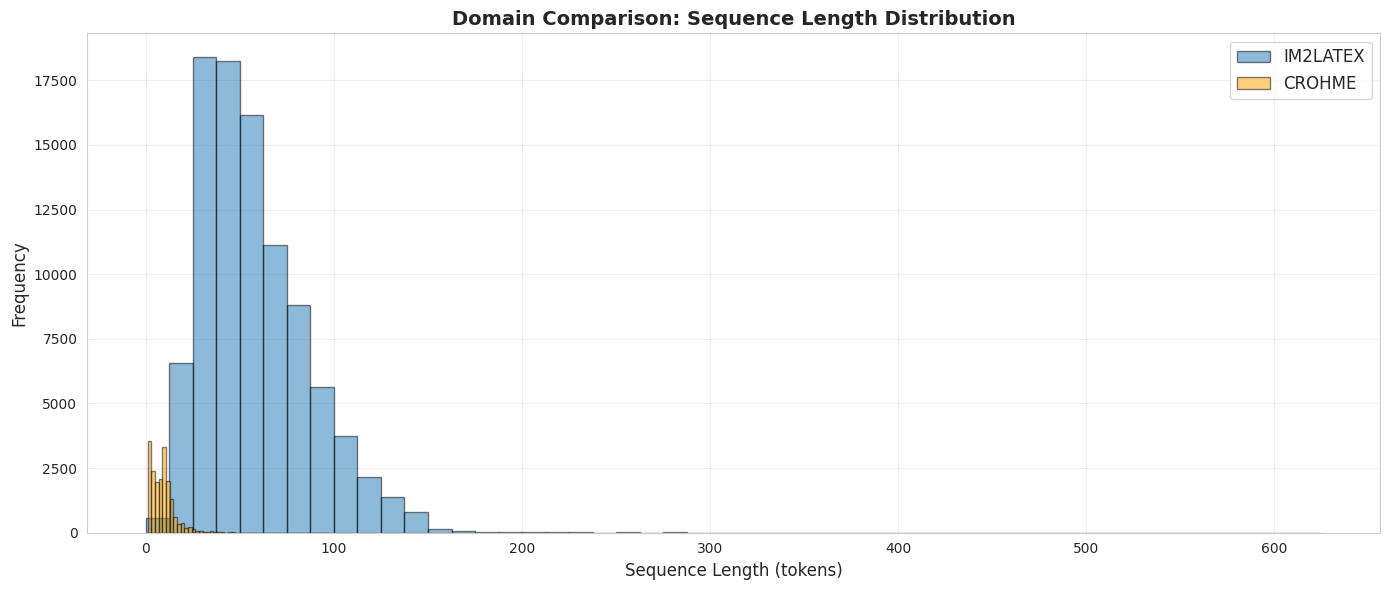


=== Sequence Length Statistics ===
IM2LATEX - Mean: 57.7, Median: 52.0
CROHME   - Mean: 8.4, Median: 8.0


In [23]:
# Overlay histogram
plt.figure(figsize=(14, 6))

plt.hist(im2latex_df['seq_len'], bins=50, alpha=0.5, label='IM2LATEX', edgecolor='black')
plt.hist(crohme_df['seq_len'], bins=50, alpha=0.5, label='CROHME', edgecolor='black', color='orange')

plt.xlabel('Sequence Length (tokens)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Domain Comparison: Sequence Length Distribution', fontsize=14, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n=== Sequence Length Statistics ===")
print(f"IM2LATEX - Mean: {im2latex_df['seq_len'].mean():.1f}, Median: {im2latex_df['seq_len'].median():.1f}")
print(f"CROHME   - Mean: {crohme_df['seq_len'].mean():.1f}, Median: {crohme_df['seq_len'].median():.1f}")

## 4.2 Aspect Ratio Comparison

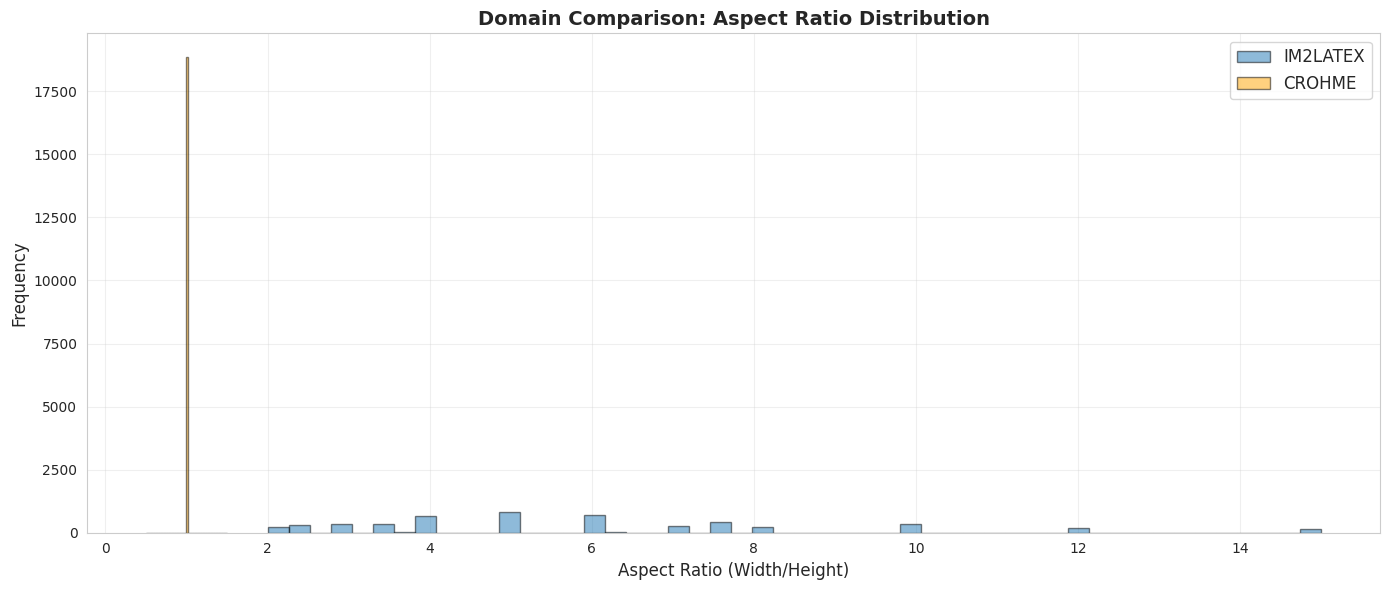


=== Aspect Ratio Statistics ===
IM2LATEX - Mean: 5.85, Median: 5.00
CROHME   - Mean: 1.00, Median: 1.00


In [24]:
# Overlay aspect ratio histogram
plt.figure(figsize=(14, 6))

plt.hist(im2latex_clean['aspect_ratio'], bins=50, alpha=0.5, label='IM2LATEX', edgecolor='black')
plt.hist(crohme_clean['aspect_ratio'], bins=50, alpha=0.5, label='CROHME', edgecolor='black', color='orange')

plt.xlabel('Aspect Ratio (Width/Height)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Domain Comparison: Aspect Ratio Distribution', fontsize=14, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n=== Aspect Ratio Statistics ===")
print(f"IM2LATEX - Mean: {im2latex_clean['aspect_ratio'].mean():.2f}, Median: {im2latex_clean['aspect_ratio'].median():.2f}")
print(f"CROHME   - Mean: {crohme_clean['aspect_ratio'].mean():.2f}, Median: {crohme_clean['aspect_ratio'].median():.2f}")

## 4.3 Nesting Depth Comparison

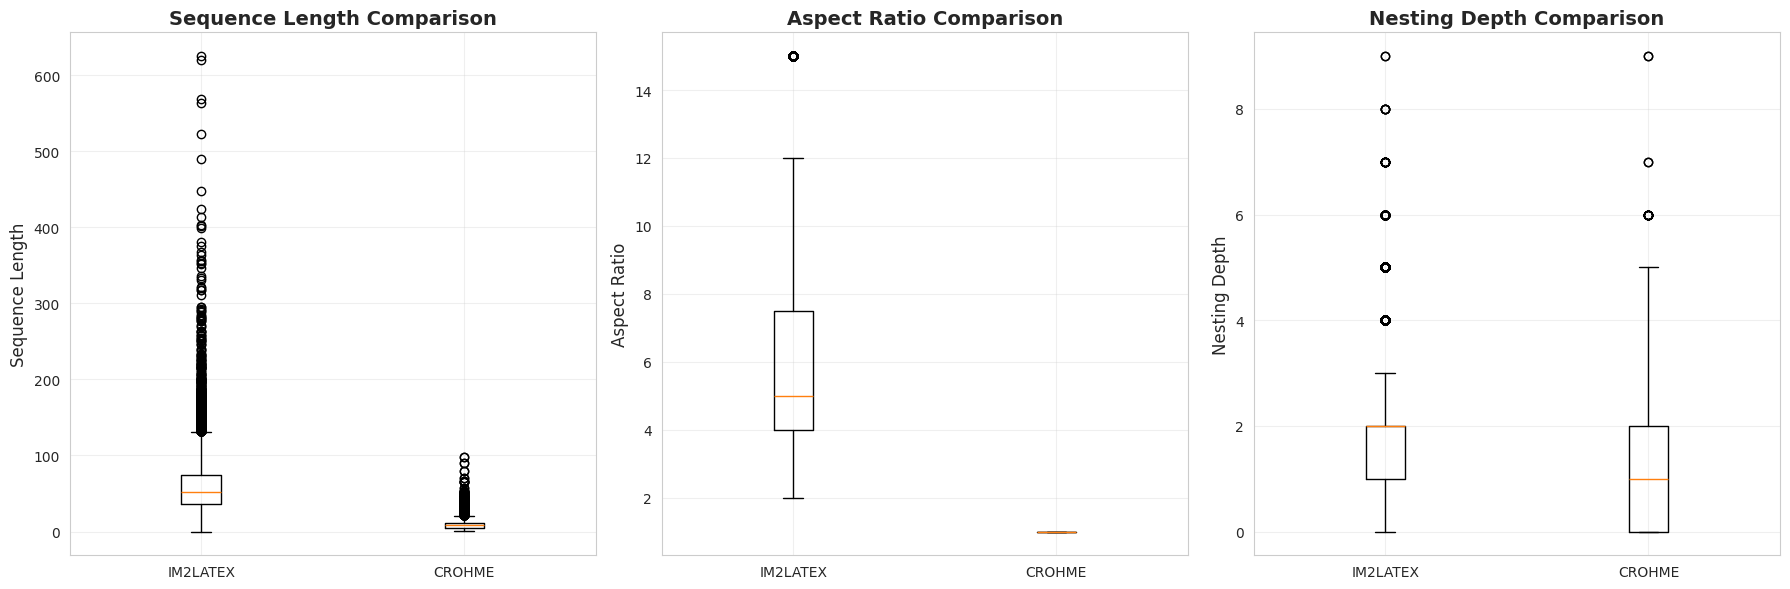

In [25]:
# Box plot comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Sequence Length
data_seq = [im2latex_df['seq_len'], crohme_df['seq_len']]
axes[0].boxplot(data_seq, labels=['IM2LATEX', 'CROHME'])
axes[0].set_ylabel('Sequence Length', fontsize=12)
axes[0].set_title('Sequence Length Comparison', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Aspect Ratio
data_aspect = [im2latex_clean['aspect_ratio'].dropna(), crohme_clean['aspect_ratio'].dropna()]
axes[1].boxplot(data_aspect, labels=['IM2LATEX', 'CROHME'])
axes[1].set_ylabel('Aspect Ratio', fontsize=12)
axes[1].set_title('Aspect Ratio Comparison', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# Nesting Depth
data_nest = [im2latex_df['nesting_depth'], crohme_df['nesting_depth']]
axes[2].boxplot(data_nest, labels=['IM2LATEX', 'CROHME'])
axes[2].set_ylabel('Nesting Depth', fontsize=12)
axes[2].set_title('Nesting Depth Comparison', fontsize=14, fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

1. Pretrain–Fine-tune là bắt buộc
- Pretrain encoder + decoder trên IM2LATEX
- Fine-tune encoder là chính trên CROHME
- Decoder freeze hoặc LR rất nhỏ

2. Preprocessing phải khác nhau
- IM2LATEX: normalize nhẹ
- CROHME: per-image norm + contrast augment

3. Max settings phải theo IM2LATEX
- max_seq_len
- max_width
- positional embedding

---

# PHẦN 5: TỔNG KẾT CHI TIẾT VÀ PHÂN TÍCH

Sau khi phân tích toàn bộ dữ liệu, đây là những phát hiện quan trọng:


## 5.1. Phân tích về KÍCH THƯỚC và ĐỊNH DẠNG ẢNH

### IM2LATEX (Ảnh in - Printed):
- **Số lượng**: 94,000 samples (83% tổng dataset)
- **Kích thước trung bình**: 283.9 × 53.3 pixels
- **Aspect Ratio**: ~5.85 (rất ngang, công thức in trên giấy)
- **Đặc điểm**:
  - Ảnh sắc nét, độ tương phản cao (std = 0.1888)
  - Pixel mean = 0.9449 (nền trắng, chữ đen)
  - Width rất đa dạng (std = 113.6), height ổn định hơn
  - 90th percentile: 480×64, 99th percentile: 480×128

### CROHME (Ảnh viết tay - Handwritten):
- **Số lượng**: 18,855 samples (17% tổng dataset)
- **Kích thước**: **Tất cả đều 400×400** (đã được resize về square!)
- **Aspect Ratio**: 1.0 (hình vuông)
- **Đặc điểm**:
  - Ảnh mờ hơn, độ tương phản thấp hơn (std = 0.1032)
  - Pixel mean = 0.9889 (nền gần như trắng hoàn toàn)
  - **LƯU Ý QUAN TRỌNG**: Ảnh CROHME đã bị resize về 400×400, mất đi aspect ratio gốc!

### 🚨 VẤN ĐỀ NGHIÊM TRỌNG:
1. **CROHME đã bị resize sai**: Tất cả ảnh đều 400×400, mất thông tin aspect ratio tự nhiên
2. **Domain gap lớn**: IM2LATEX ngang dài (5.85), CROHME vuông (1.0)
3. **Preprocessing không nhất quán**: Cần kiểm tra lại preprocessing pipeline của CROHME


## 5.2. Phân tích về SEQUENCE LENGTH (LaTeX)

### IM2LATEX:
- **Mean**: 57.7 tokens
- **Median**: 52 tokens  
- **Std**: 29.3 tokens (độ biến thiên cao)
- **Max**: 625 tokens (có công thức cực dài!)
- **Percentiles**:
  - 90%: ≤ 97 tokens
  - 95%: ≤ 113 tokens
  - 99%: ≤ 141 tokens
  
### CROHME:
- **Mean**: 8.4 tokens (ngắn hơn IM2LATEX **7 lần**!)
- **Median**: 8 tokens
- **Std**: 6.7 tokens
- **Max**: 98 tokens
- **Percentiles**:
  - 90%: ≤ 16 tokens
  - 95%: ≤ 20 tokens
  - 99%: ≤ 33 tokens

### 📊 NHẬN XÉT:
1. **CROHME công thức rất ngắn**: Chỉ ~8 tokens trung bình vs 57 của IM2LATEX
2. **IM2LATEX đa dạng hơn nhiều**: Có cả công thức cực ngắn và cực dài
3. **Imbalance nghiêm trọng**: Model pretrain trên IM2LATEX sẽ quen với sequence dài, khi fine-tune trên CROHME có thể bị overshoot
4. **MAX_SEQ_LEN**: Nên chọn theo IM2LATEX (150-200 tokens) để cover được toàn bộ dữ liệu pretrain


## 5.3. Phân tích VOCABULARY và TOKEN DISTRIBUTION

### IM2LATEX:
- **Unique tokens**: 562 (vocabulary nhỏ gọn)
- **Total tokens**: 5,424,285
- **Token distribution**: Tuân theo Zipf's law (vài token xuất hiện rất nhiều, phần lớn token hiếm)
- **Rare tokens** (count < 5): Cần kiểm tra chi tiết

### CROHME:  
- **Unique tokens**: 4,853 (nhiều hơn IM2LATEX **8.6 lần** dù dataset nhỏ hơn!)
- **Total tokens**: 157,674 (ít hơn IM2LATEX **34 lần**)
- **Token distribution**: Cũng follow Zipf's law nhưng long-tail dài hơn

### 🚨 VẤN ĐỀ NGHIÊM TRỌNG:
1. **CROHME có quá nhiều unique tokens**: 4,853 tokens cho chỉ 18k samples → có noise/typo/inconsistent labeling!
2. **IM2LATEX sạch hơn**: Chỉ 562 tokens cho 94k samples → labeling nhất quán
3. **Vocabulary mismatch**: Nhiều token trong CROHME không xuất hiện trong IM2LATEX → model sẽ gặp OOV tokens

### 💡 KHUYẾN NGHỊ:
- **Phải clean CROHME labels**: Loại bỏ typo, chuẩn hóa notation
- **Build vocabulary từ IM2LATEX**: Sử dụng vocab của IM2LATEX làm base, thêm CROHME-specific tokens nếu cần
- **Filter rare tokens**: Tokens xuất hiện < 5 lần nên map về `<UNK>`


## 5.4. Phân tích STRUCTURAL COMPLEXITY

### Nesting Depth (Độ sâu lồng nhau của dấu ngoặc):

**IM2LATEX**:
- Mean: 1.79
- Median: 2
- Max: 9
- Công thức phức tạp hơn, nhiều nested structures

**CROHME**:
- Mean: 1.09  
- Median: 1
- Max: 9
- Công thức đơn giản hơn, ít nesting

### 📊 NHẬN XÉT:
1. **IM2LATEX phức tạp hơn**: Nhiều nested fractions, subscripts, superscripts
2. **CROHME đơn giản hơn**: Chủ yếu là công thức cơ bản, ít nested
3. **Training strategy**: Model cần học từ IM2LATEX để handle complex structures trước, sau đó adapt xuống CROHME đơn giản hơn


## 5.5. DOMAIN GAP ANALYSIS - Phân tích khoảng cách giữa 2 dataset

### So sánh tổng quan:

| Metric | IM2LATEX | CROHME | Gap |
|--------|----------|---------|-----|
| **Số lượng** | 94,000 | 18,855 | **5:1** |
| **Image size** | 284×53 (varied) | 400×400 (fixed) | **Khác biệt lớn** |
| **Aspect ratio** | 5.85 | 1.0 | **5.85x** |
| **Pixel mean** | 0.9449 | 0.9889 | Bright hơn |
| **Pixel std** | 0.1888 | 0.1032 | **Contrast thấp hơn** |
| **Seq length** | 57.7 | 8.4 | **7x ngắn hơn** |
| **Vocab size** | 562 | 4,853 | **Noisy hơn** |
| **Nesting depth** | 1.79 | 1.09 | **Đơn giản hơn** |

### 🔥 DOMAIN GAP NGHIÊM TRỌNG:

1. **Visual gap**: 
   - IM2LATEX: ngang dài, sắc nét, in máy
   - CROHME: hình vuông (đã resize sai!), mờ hơn, viết tay

2. **Semantic gap**:
   - IM2LATEX: công thức dài, phức tạp, nhiều nested structures
   - CROHME: công thức ngắn, đơn giản, ít nesting

3. **Data quality gap**:
   - IM2LATEX: clean, consistent labeling
   - CROHME: nhiều noise trong labels (4,853 unique tokens!)

### ⚠️ HỆ QUẢ:
- **Transfer learning khó**: Model pretrain trên IM2LATEX sẽ rất khó adapt sang CROHME do gap quá lớn
- **Encoder mismatch**: Encoder học từ ảnh ngang dài (5.85) sẽ gặp khó với ảnh vuông (1.0)
- **Decoder mismatch**: Decoder quen sequence dài (57 tokens) sẽ có thể overshoot khi generate sequence ngắn (8 tokens)
- **Vocabulary mismatch**: OOV tokens khi transfer
